### Logistic Regression for fashion_dataset

In [15]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
X, y = fetch_openml(name='Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

# Normalizing the pixel values to a range of [0, 1]
X = X / 255.0

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
subset_size = 5000
X_train_subset = X_train_scaled[:subset_size]
y_train_subset = y_train[:subset_size]
# Initializing and training the Logistic Regression model
logistic_model = LogisticRegression(
    solver='saga',
    multi_class='multinomial',
    max_iter=500,  # Increase max_iter for better convergence
    verbose=1,
    n_jobs=-1  # Use all available cores
)
logistic_model.fit(X_train_subset, y_train_subset)

# Making predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_scaled)

c:\Users\79639\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


max_iter reached after 114 seconds


c:\Users\79639\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [17]:
import joblib
# Save the model to a file
joblib.dump(logistic_model, 'logistic_regression_fashion_mnist.joblib')
print("Model saved successfully as 'logistic_regression_fashion_mnist.joblib'")

Model saved successfully as 'logistic_regression_fashion_mnist.joblib'


Logistic Regression Model Accuracy: 0.8294

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1394
           1       0.96      0.96      0.96      1402
           2       0.74      0.71      0.72      1407
           3       0.86      0.85      0.85      1449
           4       0.71      0.77      0.74      1357
           5       0.91      0.89      0.90      1449
           6       0.60      0.57      0.58      1407
           7       0.86      0.92      0.89      1359
           8       0.95      0.92      0.93      1342
           9       0.94      0.92      0.93      1434

    accuracy                           0.83     14000
   macro avg       0.83      0.83      0.83     14000
weighted avg       0.83      0.83      0.83     14000



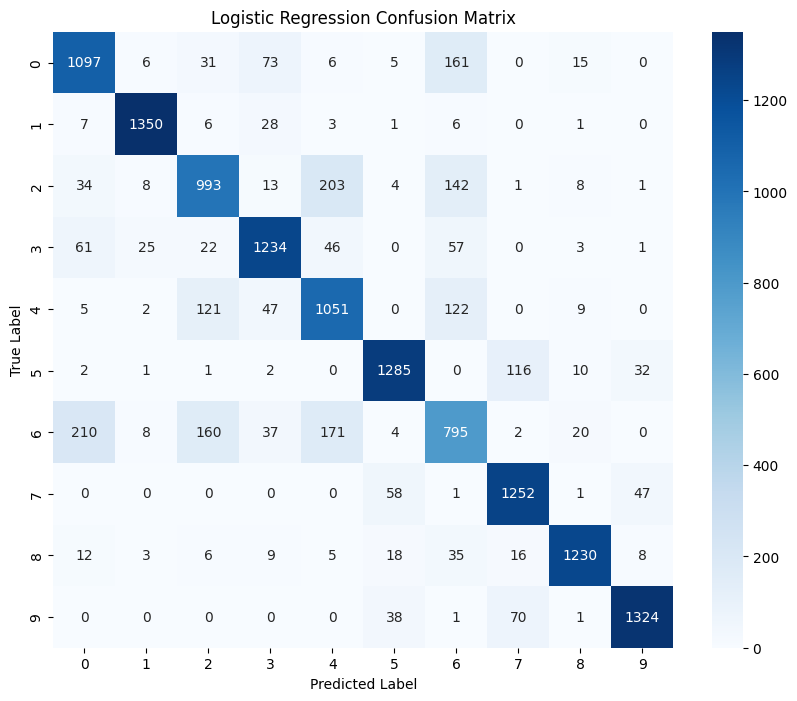

In [18]:
# Calculating and printing the accuracy score
accuracy = accuracy_score(y_test, y_pred_logistic)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}\n")

# Generating the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_logistic))

# Generatng and ploting the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_logistic)
class_labels = sorted(np.unique(y))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Logistic Regression for fashion_dataset using dimensionality reduction PCA

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X, y = fetch_openml(name='Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {pca.n_components_}")

Original number of features: 784
Reduced number of features: 256


In [ ]:
log_reg_pca = LogisticRegression(solver='saga', multi_class='multinomial', max_iter=200, verbose=1, n_jobs=-1)
log_reg_pca.fit(X_train_pca, y_train)

y_pred_pca = log_reg_pca.predict(X_test_pca)
print("\nLogistic Regression with PCA Classification Report:")
print(classification_report(y_test, y_pred_pca))

c:\Users\79639\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


max_iter reached after 163 seconds

Logistic Regression with PCA Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1394
           1       0.97      0.96      0.97      1402
           2       0.77      0.75      0.76      1407
           3       0.86      0.88      0.87      1449
           4       0.74      0.79      0.76      1357
           5       0.93      0.93      0.93      1449
           6       0.65      0.59      0.61      1407
           7       0.90      0.93      0.92      1359
           8       0.95      0.94      0.95      1342
           9       0.95      0.94      0.95      1434

    accuracy                           0.85     14000
   macro avg       0.85      0.85      0.85     14000
weighted avg       0.85      0.85      0.85     14000



c:\Users\79639\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression Model Accuracy: 0.8524



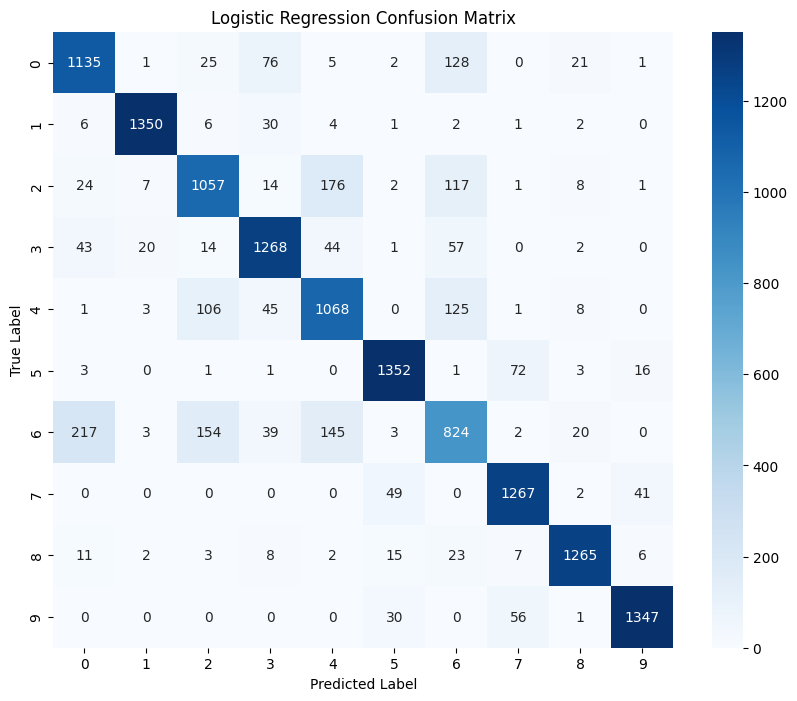

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred_pca)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}\n")

conf_matrix = confusion_matrix(y_test, y_pred_pca)
class_labels = sorted(np.unique(y))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
0: T-shirt/top

1: Trouser

2: Pullover

3: Dress

4: Coat

5: Sandal

6: Shirt

7: Sneaker

8: Bag

9: Ankle boot